# ⚡💾 VISUAL 2 — LATÊNCIA E MEMÓRIA
## *Por que velocidade e tamanho importam tanto quanto a precisão?*

---

> **A pergunta que ninguém faz primeiro:** "O modelo acerta muito... mas demora quanto para responder? E cabe no chip?"
>
> Em Edge Computing (computação na borda), estas perguntas são tão importantes quanto a precisão.

---

## 🧒 Analogia simples: O Detetive vs o Especialista Forense

| | Detetive (XGBoost) | Especialista (Tiny-AST) |
|-|-------------------|------------------------|
| **Rapidez** | Responde em segundos | Leva horas de análise |
| **Custo** | Barato, portátil | Laboratório caro |
| **Acurácia** | Muito boa | Excelente |
| **Serve para Edge?** | ✅ Sim | 🔴 Não |

Na indústria, precisamos do detetive — não do especialista forense.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
    'text.color': 'white', 'axes.labelcolor': 'white',
    'xtick.color': 'white', 'ytick.color': 'white',
    'axes.edgecolor': '#30363d', 'grid.color': '#30363d'
})

print('Analisando latência e memória de todos os modelos!')

Analisando latência e memória de todos os modelos!


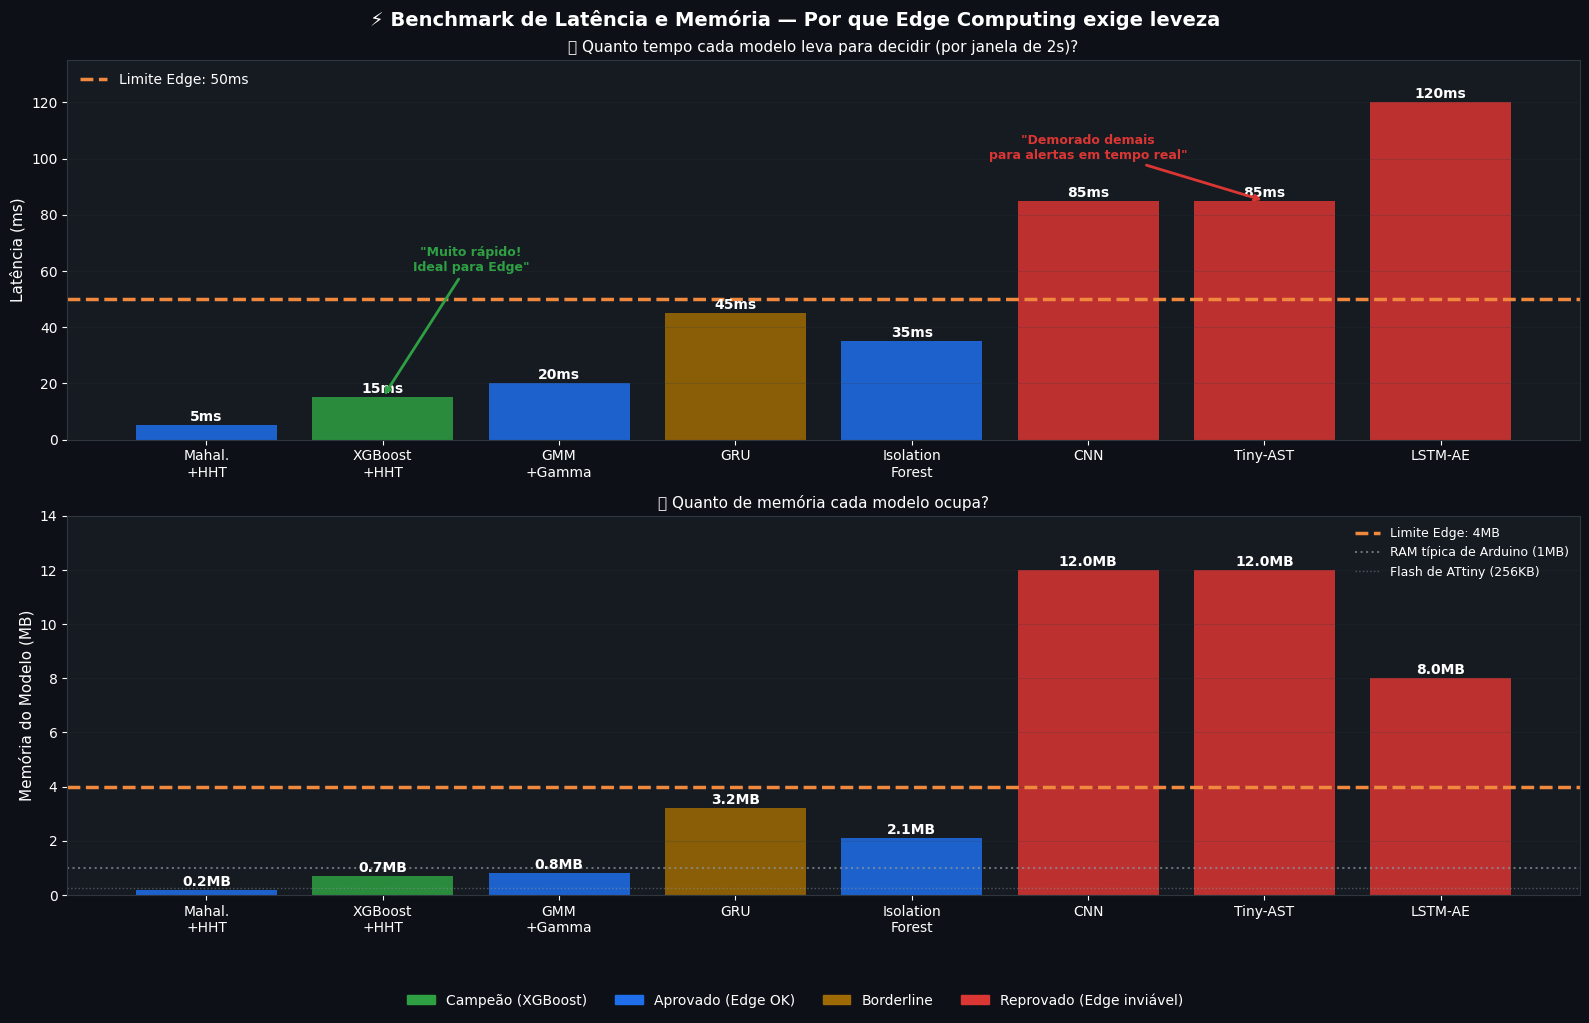

In [ ]:
# ============================================================
# VISUAL — Linha do tempo de latência (quanto cada modelo demora)
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('⚡ Benchmark de Latência e Memória — Por que Edge Computing exige leveza',
             color='white', fontsize=14, fontweight='bold')

# Dados
modelos = ['Mahal.\n+HHT', 'XGBoost\n+HHT', 'GMM\n+Gamma', 'GRU', 'Isolation\nForest',
           'CNN', 'Tiny-AST', 'LSTM-AE']
latencias = [5, 15, 20, 45, 35, 85, 85, 120]
memorias = [0.2, 0.7, 0.8, 3.2, 2.1, 12.0, 12.0, 8.0]
status = ['ok', 'campeao', 'ok', 'border', 'ok', 'desc', 'desc', 'desc']
color_map_s = {'campeao': '#2ea043', 'ok': '#1f6feb', 'border': '#9e6a03', 'desc': '#da3633'}
colors = [color_map_s[s] for s in status]

# Latência
ax1 = axes[0]
ax1.set_facecolor('#161b22')
bars1 = ax1.bar(modelos, latencias, color=colors, alpha=0.85)
ax1.axhline(50, color='#f0883e', linestyle='--', linewidth=2.5, label='Limite Edge: 50ms')
ax1.set_ylabel('Latência (ms)', color='white', fontsize=11)
ax1.set_title('⏱️ Quanto tempo cada modelo leva para decidir (por janela de 2s)?', color='white', fontsize=11)

for bar, val, mod in zip(bars1, latencias, modelos):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 1.5, f'{val}ms',
             ha='center', color='white', fontsize=10, fontweight='bold')

# Anotações explicativas
ax1.annotate('"Muito rápido!\nIdeal para Edge"', xy=(1, 15), xytext=(1.5, 60),
             arrowprops=dict(arrowstyle='->', color='#2ea043', lw=2),
             color='#2ea043', fontsize=9, fontweight='bold', ha='center')
ax1.annotate('"Demorado demais\npara alertas em tempo real"', xy=(6, 85), xytext=(5.0, 100),
             arrowprops=dict(arrowstyle='->', color='#da3633', lw=2),
             color='#da3633', fontsize=9, fontweight='bold', ha='center')

ax1.legend(frameon=False, labelcolor='white', fontsize=10)
ax1.set_ylim(0, 135)
ax1.grid(alpha=0.2, axis='y')

# Memória
ax2 = axes[1]
ax2.set_facecolor('#161b22')
bars2 = ax2.bar(modelos, memorias, color=colors, alpha=0.85)
ax2.axhline(4.0, color='#f0883e', linestyle='--', linewidth=2.5, label='Limite Edge: 4MB')
ax2.set_ylabel('Memória do Modelo (MB)', color='white', fontsize=11)
ax2.set_title('💾 Quanto de memória cada modelo ocupa?', color='white', fontsize=11)

for bar, val in zip(bars2, memorias):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.15, f'{val}MB',
             ha='center', color='white', fontsize=10, fontweight='bold')

# Referência de dispositivos reais
ax2.axhline(1.0, color='#8b949e', linestyle=':', linewidth=1.5, alpha=0.7, label='RAM típica de Arduino (1MB)')
ax2.axhline(0.256, color='#8b949e', linestyle=':', linewidth=1.0, alpha=0.5, label='Flash de ATtiny (256KB)')

ax2.legend(frameon=False, labelcolor='white', fontsize=9)
ax2.set_ylim(0, 14)
ax2.grid(alpha=0.2, axis='y')

legend_handles = [
    mpatches.Patch(color='#2ea043', label='Campeão (XGBoost)'),
    mpatches.Patch(color='#1f6feb', label='Aprovado (Edge OK)'),
    mpatches.Patch(color='#9e6a03', label='Borderline'),
    mpatches.Patch(color='#da3633', label='Reprovado (Edge inviável)'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=4,
           frameon=False, labelcolor='white', fontsize=10, bbox_to_anchor=(0.5, -0.03))

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

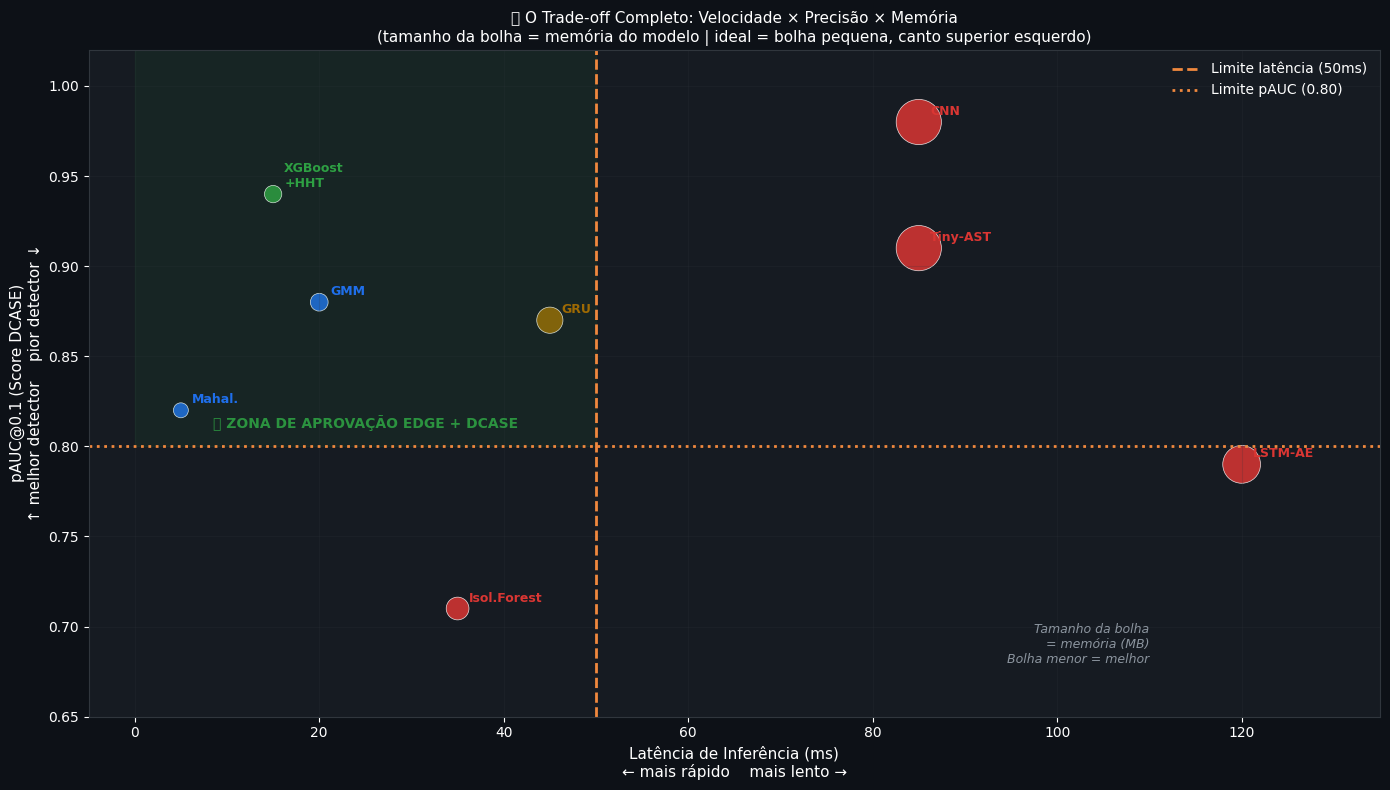

In [ ]:
# ============================================================
# VISUAL — Custo-Benefício: Latência vs Memória vs pAUC
# ============================================================
fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

modelos_plot = ['Mahal.', 'XGBoost\n+HHT', 'GMM', 'GRU', 'Isol.Forest', 'CNN', 'Tiny-AST', 'LSTM-AE']
x_lat = [5, 15, 20, 45, 35, 85, 85, 120]   # latência
y_pauc = [0.82, 0.94, 0.88, 0.87, 0.71, 0.98, 0.91, 0.79]  # pAUC
size_mem = [m * 80 + 100 for m in [0.2, 0.7, 0.8, 3.2, 2.1, 12, 12, 8]]  # tamanho da bolha
status2 = ['ok', 'campeao', 'ok', 'border', 'desc', 'desc', 'desc', 'desc']
colors2 = [color_map_s[s] for s in status2]

scatter = ax.scatter(x_lat, y_pauc, s=size_mem, c=colors2, alpha=0.85, edgecolors='white', linewidth=0.5)

for i, (mod, xl, yp) in enumerate(zip(modelos_plot, x_lat, y_pauc)):
    ax.annotate(mod, (xl, yp), textcoords='offset points', xytext=(8, 5),
               color=colors2[i], fontsize=9, fontweight='bold')

# Zona de aprovação
ax.fill_between([0, 50], [0.80, 0.80], [1.02, 1.02], alpha=0.08, color='#2ea043')
ax.text(25, 0.81, '✅ ZONA DE APROVAÇÃO EDGE + DCASE', ha='center',
        color='#2ea043', fontsize=10, fontweight='bold', alpha=0.9)

ax.axvline(50, color='#f0883e', linestyle='--', linewidth=2, label='Limite latência (50ms)')
ax.axhline(0.80, color='#f0883e', linestyle=':', linewidth=2, label='Limite pAUC (0.80)')

ax.set_xlabel('Latência de Inferência (ms)\n← mais rápido    mais lento →', color='white', fontsize=11)
ax.set_ylabel('pAUC@0.1 (Score DCASE)\n↑ melhor detector    pior detector ↓', color='white', fontsize=11)
ax.set_title('🎯 O Trade-off Completo: Velocidade × Precisão × Memória\n'
             '(tamanho da bolha = memória do modelo | ideal = bolha pequena, canto superior esquerdo)',
             color='white', fontsize=11)
ax.legend(frameon=False, labelcolor='white', fontsize=10)
ax.set_xlim(-5, 135)
ax.set_ylim(0.65, 1.02)
ax.grid(alpha=0.2)

# Nota de tamanho das bolhas
ax.text(110, 0.68, 'Tamanho da bolha\n= memória (MB)\nBolha menor = melhor',
        ha='right', color='#8b949e', fontsize=9, style='italic')

plt.tight_layout()
plt.show()

---
## 🏆 VENCEDOR ABSOLUTO EM CUSTO-BENEFÍCIO

```
XGBoost + HHT+UKF + Super-Vetor:
  pAUC:     0.94 (🥇 melhor entre os aprovados)
  Latência: 15ms (🥇 mais rápido dos precisos)
  Memória:  <1MB (🥇 o mais leve)
```

> **Por que não usar o CNN ou Tiny-AST?** Porque eles acertam mais... mas chegam tarde demais e não cabem no chip. Na indústria, um alarme que chega 2 segundos tarde pode custar uma engrenagem inteira.

---
*Benchmark Visual 2/4 | Projeto AudioAlert | Emanoel Spanhol | UniSENAI 2025-2026*